pip install vllm pandas matplotlib

In [1]:
import os, json, gc
# 关键：避免 vLLM v1 engine 多进程 core 导致的初始化失败
os.environ["VLLM_USE_V1"] = "0"
os.environ["VLLM_LOGGING_LEVEL"] = "ERROR"
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer
from vllm import LLM, SamplingParams
import math
from typing import Dict, List, Tuple

/workspace/venvs/qwen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import json, os

# def patch_config_remove_compressed_tensors(model_dir: str):
#     cfg_path = os.path.join(model_dir, "config.json")
#     with open(cfg_path, "r", encoding="utf-8") as f:
#         cfg = json.load(f)

#     removed = []
#     # config.json里有quantization_config，且里面有 quant_method
#     qc = cfg.get("quantization_config", None)
#     if isinstance(qc, dict) and qc.get("quant_method") == "compressed-tensors":
#         cfg.pop("quantization_config", None)
#         removed.append("quantization_config")

#     # 有些版本也会用 quantization / quant_method 顶层字段
#     if cfg.get("quant_method") == "compressed-tensors":
#         cfg.pop("quant_method", None)
#         removed.append("quant_method")

#     if cfg.get("quantization") == "compressed-tensors":
#         cfg.pop("quantization", None)
#         removed.append("quantization")

#     with open(cfg_path, "w", encoding="utf-8") as f:
#         json.dump(cfg, f, ensure_ascii=False, indent=2)

#     print(f"[OK] patched {model_dir}, removed={removed}")

# patch_config_remove_compressed_tensors("/root/out/llama-31-8b-pruned-sft-merged-bf16")
# patch_config_remove_compressed_tensors("/root/out/llama-31-8b-pruned-kd-merged-bf16")

In [3]:
# ====== paths ======
EVAL_MANIFEST = "/root/data/eval_data/manifest.json"

# 要评测的两个模型（建议用 merged bf16，或量化模型路径）
MODEL_SFT = "/root/out/llama-31-8b-pruned-sft-merged-bf16"
MODEL_KD  = "/root/out/llama-31-8b-pruned-kd-merged-bf16"
MODEL_BASE = "meta-llama/Llama-3.1-8B-Instruct"

# vLLM runtime knobs（跑通优先）
DTYPE = "bfloat16"           # 不支持就改 "float16"
GPU_MEMORY_UTIL = 0.90
MAX_MODEL_LEN = 2048

# batch size：越大越快，但显存更吃紧；先用 64/128
BATCH_SIZE = 64

# 评测每个数据集取多少样本（<= 你导出的 jsonl 行数）
N_MAX_PER_DATASET = None     # None 表示用全量（比如导出 2000 就跑 2000）

# logprobs top-k：必须 >= 选项数量（通常 4），给 20 更稳
TOP_LOGPROBS = 20

In [4]:
def load_manifest(path: str) -> List[Dict]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_jsonl(path: str, n_max=None) -> List[Dict]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
            if n_max is not None and len(rows) >= n_max:
                break
    return rows

def letters(k: int) -> List[str]:
    return [chr(ord("A")+i) for i in range(k)]

def get_letter_token_ids(tok: AutoTokenizer, k: int) -> Dict[str, List[int]]:
    """
    为了稳：同时考虑 "A" 和 " A" 两种 tokenization。
    返回：每个字母 -> 可能的 token_id 列表（去重）。
    """
    mapping = {}
    for L in letters(k):
        ids = set()
        for s in [L, " " + L]:
            enc = tok.encode(s, add_special_tokens=False)
            # 我们只用单 token 的情况来做 next-token 评分；多 token 直接跳过
            if len(enc) == 1:
                ids.add(enc[0])
        mapping[L] = sorted(list(ids))
    return mapping

def chunked(lst, bs):
    for i in range(0, len(lst), bs):
        yield lst[i:i+bs]

In [5]:
def eval_mc_next_token_logprob(
    model_path: str,
    manifest_path: str,
    dtype: str = "bfloat16",
    gpu_memory_utilization: float = 0.90,
    max_model_len: int = 2048,
    batch_size: int = 64,
    top_logprobs: int = 20,
    n_max_per_dataset=None,
) -> pd.DataFrame:
    """
    对 manifest 里每个 jsonl 评测 accuracy：
    - prompt 末尾补一个空格
    - 生成 1 token，取该 token 的 logprobs（top-k）
    - 在候选字母 token (A/B/C/...) 中选 logprob 最大的字母
    """
    manifest = load_manifest(manifest_path)

    print(f"Loading tokenizer: {MODEL_BASE}") # use the same tokenizer for all models
    tok = AutoTokenizer.from_pretrained(MODEL_BASE, use_fast=True, trust_remote_code=True)

    print(f"Loading vLLM model: {model_path}")
    llm = LLM(
        model=model_path,
        dtype=dtype,
        gpu_memory_utilization=gpu_memory_utilization,
        max_model_len=max_model_len,
        trust_remote_code=True,
    )

    sp = SamplingParams(
        temperature=0.0,
        max_tokens=1,
        logprobs=top_logprobs,
    )

    all_rows = []
    for item in manifest:
        name = item["name"]
        path = item["path"]
        rows = read_jsonl(path, n_max=n_max_per_dataset)
        if len(rows) == 0:
            continue

        # 选项数量可能不同（TruthfulQA 有时 >4）
        k = len(rows[0]["choices"])
        letter_ids = get_letter_token_ids(tok, k)
        cand_letters = letters(k)

        # 构造 prompts
        prompts = []
        answers = []
        for ex in rows:
            prompt = ex["messages"][0]["content"]
            # 关键：末尾加空格，让答案字母更容易成为单 token（" A"）
            if not prompt.endswith(" "):
                prompt = prompt + " "
            prompts.append(prompt)
            answers.append(int(ex["answer_index"]))

        # 推理
        correct = 0
        total = 0
        unknown = 0

        for batch_prompts, batch_answers in zip(chunked(prompts, batch_size), chunked(answers, batch_size)):
            outs = llm.generate(batch_prompts, sp)

            for out, gt in zip(outs, batch_answers):
                total += 1

                # vLLM: out.outputs[0].logprobs is a list (len=max_tokens) of dict[token_id] -> Logprob
                if not out.outputs:
                    unknown += 1
                    continue
                lp_dict = out.outputs[0].logprobs[0]  # first generated token logprobs dict

                # 从候选字母 token id 中找最大 logprob
                best_letter = None
                best_lp = -1e30
                for L in cand_letters:
                    ids = letter_ids.get(L, [])
                    for tid in ids:
                        if tid in lp_dict:
                            lp = lp_dict[tid].logprob
                            if lp > best_lp:
                                best_lp = lp
                                best_letter = L

                # 如果 top-k 里没出现候选 token（偶发），fallback：用生成文本 parse
                if best_letter is None:
                    gen = (out.outputs[0].text or "").strip()
                    if gen:
                        c = gen[0].upper()
                        if c in cand_letters:
                            best_letter = c
                        else:
                            unknown += 1
                            continue
                    else:
                        unknown += 1
                        continue

                pred = ord(best_letter) - ord("A")
                if pred == gt:
                    correct += 1

        acc = correct / max(total - 0, 1)
        all_rows.append({
            "model": os.path.basename(model_path.rstrip("/")),
            "dataset": name,
            "n": total,
            "acc": acc,
            "unknown": unknown,
            "unknown_rate": unknown / max(total, 1),
            "k_choices": k
        })
        print(f"{name:14s}  acc={acc:.4f}  n={total}  unknown={unknown} ({unknown/max(total,1):.2%})")

    df = pd.DataFrame(all_rows)

    # overall (micro-average)
    if len(df) > 0:
        total_n = df["n"].sum()
        overall = (df["acc"] * df["n"]).sum() / max(total_n, 1)
        df_overall = pd.DataFrame([{
            "model": os.path.basename(model_path.rstrip("/")),
            "dataset": "overall_micro",
            "n": int(total_n),
            "acc": float(overall),
            "unknown": int(df["unknown"].sum()),
            "unknown_rate": float(df["unknown"].sum() / max(total_n, 1)),
            "k_choices": None
        }])
        df = pd.concat([df, df_overall], ignore_index=True)

    return df, llm  # 返回 llm 方便显式释放

In [6]:
df_sft, llm_sft = eval_mc_next_token_logprob(
    model_path=MODEL_SFT,
    manifest_path=EVAL_MANIFEST,
    dtype=DTYPE,
    gpu_memory_utilization=GPU_MEMORY_UTIL,
    max_model_len=MAX_MODEL_LEN,
    batch_size=BATCH_SIZE,
    top_logprobs=TOP_LOGPROBS,
    n_max_per_dataset=N_MAX_PER_DATASET,
)

df_sft

Loading tokenizer: meta-llama/Llama-3.1-8B-Instruct


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
2026-03-02 11:04:55,343	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loading vLLM model: /root/out/llama-31-8b-pruned-sft-merged-bf16


The tokenizer you are loading from '/root/out/llama-31-8b-pruned-sft-merged-bf16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


...

Processed prompts: 100%|██████████| 51/51 [00:00<00:00, 173.80it/s, est. speed input: 11338.52 toks/s, output: 174.22 toks/s]


winogrande      acc=0.5328  n=1267  unknown=0 (0.00%)


Processed prompts: 100%|██████████| 49/49 [00:00<00:00, 76.20it/s, est. speed input: 8495.46 toks/s, output: 76.28 toks/s]

truthfulqa_mc   acc=0.2962  n=817  unknown=0 (0.00%)


,model,dataset,n,acc,unknown,unknown_rate,k_choices
0,llama-31-8b-pruned-sft-merged-bf16,hellaswag,5000,0.428200,0,0.0,4
1,llama-31-8b-pruned-sft-merged-bf16,arc_challenge,1172,0.604949,0,0.0,4
2,llama-31-8b-pruned-sft-merged-bf16,winogrande,1267,0.532755,0,0.0,2
3,llama-31-8b-pruned-sft-merged-bf16,truthfulqa_mc,817,0.296206,0,0.0,10
4,llama-31-8b-pruned-sft-merged-bf16,overall_micro,8256,0.456274,0,0.0,None


In [7]:
# --- IMPORTANT: release SFT model before evaluating KD ---
del llm_sft
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Released SFT model.")

Released SFT model.


In [8]:
df_kd, llm_kd = eval_mc_next_token_logprob(
    model_path=MODEL_KD,
    manifest_path=EVAL_MANIFEST,
    dtype=DTYPE,
    gpu_memory_utilization=GPU_MEMORY_UTIL,
    max_model_len=MAX_MODEL_LEN,
    batch_size=BATCH_SIZE,
    top_logprobs=TOP_LOGPROBS,
    n_max_per_dataset=N_MAX_PER_DATASET,
)

df_kd

Loading tokenizer: meta-llama/Llama-3.1-8B-Instruct


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading vLLM model: /root/out/llama-31-8b-pruned-kd-merged-bf16


The tokenizer you are loading from '/root/out/llama-31-8b-pruned-kd-merged-bf16' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


...

Processed prompts: 100%|██████████| 51/51 [00:00<00:00, 170.39it/s, est. speed input: 11114.68 toks/s, output: 170.78 toks/s]


winogrande      acc=0.5383  n=1267  unknown=0 (0.00%)


Processed prompts: 100%|██████████| 49/49 [00:00<00:00, 74.99it/s, est. speed input: 8359.45 toks/s, output: 75.06 toks/s]

truthfulqa_mc   acc=0.3501  n=817  unknown=0 (0.00%)


,model,dataset,n,acc,unknown,unknown_rate,k_choices
0,llama-31-8b-pruned-kd-merged-bf16,hellaswag,5000,0.439400,0,0.0,4
1,llama-31-8b-pruned-kd-merged-bf16,arc_challenge,1172,0.623720,0,0.0,4
2,llama-31-8b-pruned-kd-merged-bf16,winogrande,1267,0.538279,0,0.0,2
3,llama-31-8b-pruned-kd-merged-bf16,truthfulqa_mc,817,0.350061,0,0.0,10
4,llama-31-8b-pruned-kd-merged-bf16,overall_micro,8256,0.471899,0,0.0,None


In [9]:
del llm_kd
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Released KD model.")

Released KD model.


In [10]:
df_base, llm_base = eval_mc_next_token_logprob(
    model_path=MODEL_BASE,
    manifest_path=EVAL_MANIFEST,
    dtype=DTYPE,
    gpu_memory_utilization=GPU_MEMORY_UTIL,
    max_model_len=MAX_MODEL_LEN,
    batch_size=BATCH_SIZE,
    top_logprobs=TOP_LOGPROBS,
    n_max_per_dataset=N_MAX_PER_DATASET,
)

df_base

Loading tokenizer: meta-llama/Llama-3.1-8B-Instruct


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading vLLM model: meta-llama/Llama-3.1-8B-Instruct
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:01,  2.56it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  2.22it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.15it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.76it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.55it/s]
(EngineCore_DP0 pid=6199) 
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 23.13it/s]
Processed prompts: 100%|██████████| 8/8 [00:00<00:00, 35.30it/s, est. speed input: 6982.32 toks/s, output: 35.42 toks/s]


hellaswag       acc=0.7092  n=5000  unknown=0 (0.00%)


...

Processed prompts: 100%|██████████| 51/51 [00:00<00:00, 173.61it/s, est. speed input: 11308.88 toks/s, output: 173.77 toks/s]


winogrande      acc=0.6425  n=1267  unknown=0 (0.00%)


Processed prompts: 100%|██████████| 49/49 [00:00<00:00, 76.82it/s, est. speed input: 8566.53 toks/s, output: 76.92 toks/s]

truthfulqa_mc   acc=0.5471  n=817  unknown=0 (0.00%)


,model,dataset,n,acc,unknown,unknown_rate,k_choices
0,Llama-3.1-8B-Instruct,hellaswag,5000,0.709200,0,0.0,4
1,Llama-3.1-8B-Instruct,arc_challenge,1172,0.814846,0,0.0,4
2,Llama-3.1-8B-Instruct,winogrande,1267,0.642463,0,0.0,2
3,Llama-3.1-8B-Instruct,truthfulqa_mc,817,0.547124,0,0.0,10
4,Llama-3.1-8B-Instruct,overall_micro,8256,0.697917,0,0.0,None


In [11]:
del llm_base
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Released BASE model.")

Released BASE model.


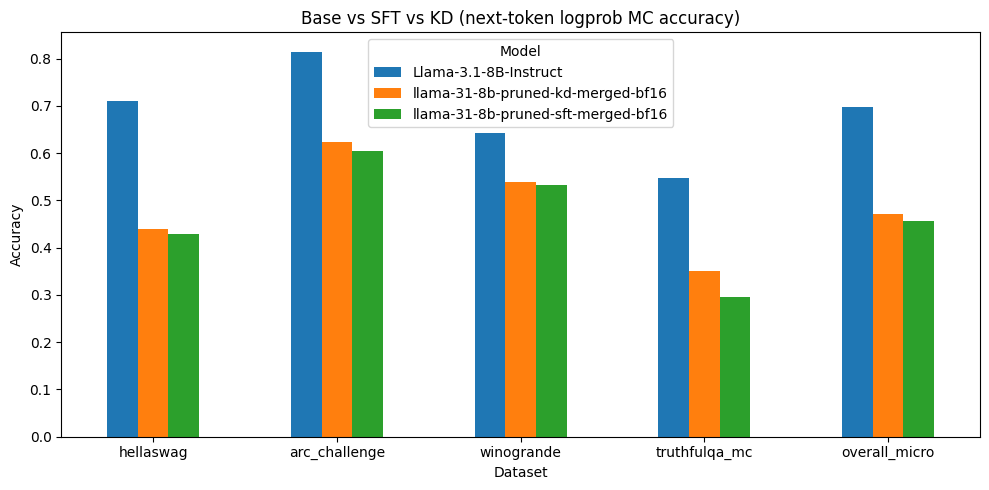

In [12]:
# 先把三者拼起来
df_all = pd.concat([df_base, df_sft, df_kd], ignore_index=True)

# 排序 & 画图
order = ["hellaswag", "arc_challenge", "winogrande", "truthfulqa_mc", "overall_micro"]

df_plot = df_all.copy()
df_plot["dataset"] = pd.Categorical(df_plot["dataset"], categories=order, ordered=True)
df_plot = df_plot.sort_values(["dataset", "model"])

# pivot for plotting
datasets = [d for d in order if d in df_plot["dataset"].unique().tolist()]
pv = df_plot.pivot(index="dataset", columns="model", values="acc").loc[datasets]

ax = pv.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Accuracy")
ax.set_xlabel("Dataset")
ax.set_title("Base vs SFT vs KD (next-token logprob MC accuracy)")
ax.legend(title="Model", loc="best")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()